# Model Preprocessing

This is the preprocessing applied in production.
- Train/validation/test split
- Scaling (StandardScaler, MinMaxScaler, RobustScaler)
- Normalisation (L2 norm)
- Full imputation
- Outlier handling
- Pipeline creation (sklearn Pipelines, SageMaker Pipelines)

Scaling all the column values for training, making sure to remove values which are invalid for scaling

In [1]:
import pandas as pd

df = pd.read_pickle('data/df_nba_games.pkl')

In [2]:
df.head()

,season,date,home,team,team_opp,days_rested,days_rested_opp,mp_5_diff,fg_5_diff,fga_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
12844,2021,2020-12-27,1,LAL,MIN,2.0,1.0,0.0,6.000000,-10.0,...,3.000000,38.900000,-0.700000,71.000000,3.000000,22.000000,1.000000,0.000000,0.000000,True
12850,2021,2020-12-27,0,PHI,CLE,1.0,1.0,-10.0,1.800000,-1.0,...,-0.492222,-8.166667,-1.584444,-6.800000,5.588889,-9.966667,0.044444,-0.255556,-0.133333,False
12858,2021,2020-12-27,1,CHI,GSW,1.0,2.0,0.0,2.666667,-2.0,...,-2.166667,17.100000,0.533333,-15.666667,0.000000,8.666667,0.333333,-0.333333,0.000000,False
12840,2021,2020-12-27,0,MIL,NYK,2.0,1.0,0.0,-0.400000,-0.2,...,0.041111,-6.593333,-1.996667,-5.655556,4.600000,-7.800000,0.155556,-0.155556,-0.133333,False
12853,2021,2020-12-27,0,BOS,IND,2.0,1.0,0.0,0.000000,-1.6,...,-0.566667,10.516667,-0.216667,0.833333,-1.333333,4.833333,0.333333,0.000000,0.000000,False


In [3]:
df.describe()

,season,home,days_rested,days_rested_opp,mp_5_diff,fg_5_diff,fga_5_diff,fg%_5_diff,3p_5_diff,3pa_5_diff,...,stl%_max_10_diff,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff
count,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,1.220800e+04,12208.000000,12208.000000,...,1.220800e+04,1.220800e+04,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000
mean,2023.047510,0.500328,2.026130,2.026540,0.002628,0.001843,0.001137,1.595811e-05,0.000952,0.003143,...,1.410960e-04,2.844680e-03,0.000528,-0.000681,0.009165,0.002998,0.005542,0.000286,0.000016,0.000187
std,1.392629,0.500020,0.650202,0.650374,3.376962,2.846804,3.768988,2.976303e-02,2.107354,3.691485,...,1.509789e+00,2.418288e+00,7.077967,2.792432,13.789948,3.528606,4.118876,0.174824,0.172349,0.201053
min,2021.000000,0.000000,1.000000,1.000000,-25.000000,-17.000000,-16.600000,-1.420000e-01,-10.800000,-14.800000,...,-1.349000e+01,-1.530000e+01,-50.000000,-13.040000,-80.500000,-15.100000,-23.300000,-1.000000,-0.700000,-0.900000
25%,2022.000000,0.000000,2.000000,2.000000,0.000000,-1.800000,-2.400000,-1.860000e-02,-1.400000,-2.400000,...,-6.400000e-01,-1.190000e+00,-4.280000,-1.440000,-8.300000,-2.200000,-2.600000,-0.100000,-0.100000,-0.100000
50%,2023.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,-8.326673e-17,0.000000,0.000000,...,8.881784e-16,-1.776357e-15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.000000,1.000000,2.000000,2.000000,0.000000,1.800000,2.400000,1.920000e-02,1.400000,2.400000,...,6.200000e-01,1.180000e+00,4.210000,1.440000,8.200000,2.100000,2.500000,0.100000,0.100000,0.100000
max,2025.000000,1.000000,4.000000,4.000000,30.000000,12.000000,17.000000,1.338000e-01,9.000000,17.200000,...,1.306000e+01,1.572000e+01,38.900000,13.340000,71.000000,16.700000,22.000000,1.000000,1.000000,1.100000


In [4]:
from sklearn.preprocessing import MinMaxScaler

removed_columns = ["season", "date", "team", "team_opp", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

scaler = MinMaxScaler()
df[selected_columns] = scaler.fit_transform(df[selected_columns])

In [5]:
df['won'] = df['won'].astype(int)

In [6]:
df.head()

,season,date,home,team,team_opp,days_rested,days_rested_opp,mp_5_diff,fg_5_diff,fga_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
12844,2021,2020-12-27,1.0,LAL,MIN,0.333333,0.000000,0.454545,0.793103,0.196429,...,0.589942,1.000000,0.467779,1.000000,0.569182,1.000000,1.000000,0.411765,0.450000,1
12850,2021,2020-12-27,0.0,PHI,CLE,0.000000,0.000000,0.272727,0.648276,0.464286,...,0.477362,0.470566,0.434252,0.486469,0.650594,0.294334,0.522222,0.261438,0.383333,0
12858,2021,2020-12-27,1.0,CHI,GSW,0.000000,0.333333,0.454545,0.678161,0.434524,...,0.423383,0.754781,0.514531,0.427943,0.474843,0.705666,0.666667,0.215686,0.450000,0
12840,2021,2020-12-27,0.0,MIL,NYK,0.333333,0.000000,0.454545,0.572414,0.488095,...,0.494555,0.488264,0.418625,0.494023,0.619497,0.342163,0.577778,0.320261,0.383333,0
12853,2021,2020-12-27,0.0,BOS,IND,0.333333,0.000000,0.454545,0.586207,0.446429,...,0.474962,0.680727,0.486101,0.536854,0.432914,0.621045,0.666667,0.411765,0.450000,0


In [7]:
df.to_pickle('data/df_nba_games_processed.pkl')

# Model Selection

| **Rank** | **Model Name** | **Short Description** | **Expected Performance** |
|---------|----------------|------------------------|---------------------------|
| **1** | XGBoost | Optimized gradient boosting; extremely strong on tabular data. | High — 65–75% accuracy. |
| **2** | LightGBM | Faster, leaf-wise boosting; excels on large datasets. | High — similar or better than XGBoost. |
| **3** | CatBoost | Gradient boosting built for categorical features. | High — excellent default performance. |
| **4** | Gradient Boosting | Sequential trees improving each step. | High — strong on structured data. |
| **5** | Random Forest | Ensemble of trees reducing overfitting. | High — 60–70% accuracy. |
| **6** | Logistic Regression | Linear classifier predicting probabilities. | Moderate — 55–65%. |
| **7** | MLP (Neural Network) | Fully connected neural network. | Moderate–High — depends on dataset size. |
| **8** | Support Vector Machine (SVM) | Margin-based classifier; strong but not scalable. | Moderate–High. |
| **9** | Decision Tree | Single tree with splitting rules. | Moderate — prone to overfitting. |
| **10** | K-Nearest Neighbour (KNN) | Instance-based classifier. | Low–Moderate — poor with many features. |
| **11** | Naive Bayes | Probabilistic classifier assuming feature independence. | Moderate — fast but simplistic. |
| **12** | LSTM | RNN for long-term sequences. | High for time series; lower for tabular. |
| **13** | GRU | Efficient LSTM variant. | High for time series; lower for tabular. |
| **14** | RNN | Standard recurrent neural network. | Moderate — struggles with long sequences. |
| **15** | Linear Regression | Predicts continuous values linearly. | Low–Moderate — poor for classification. |

- Baseline vs advanced models
- Cross-validation strategy

# Model Training

In [8]:
import pandas as pd

df = pd.read_pickle('df_nba_games_processed.pkl')

In [9]:
df.head()

,season,date,home,team,team_opp,days_rested,days_rested_opp,mp_5_diff,fg_5_diff,fga_5_diff,...,blk%_max_10_diff,tov%_max_10_diff,usg%_max_10_diff,ortg_max_10_diff,drtg_max_10_diff,total_10_diff,home_10_diff,won_10_diff,days_rested_10_diff,won
12844,2021,2020-12-27,1.0,LAL,MIN,0.333333,0.000000,0.454545,0.793103,0.196429,...,0.589942,1.000000,0.467779,1.000000,0.569182,1.000000,1.000000,0.411765,0.450000,1
12846,2021,2020-12-27,0.0,ORL,WAS,0.000000,0.000000,0.636364,0.646552,0.474702,...,0.531879,0.573716,0.476666,0.686542,0.336129,0.643120,0.427778,0.562092,0.461111,1
12848,2021,2020-12-27,0.0,PHO,SAC,0.000000,0.000000,0.454545,0.724138,0.523810,...,0.491618,0.714848,0.536012,0.594059,0.647799,0.724062,0.500000,0.117647,0.450000,1
12852,2021,2020-12-27,1.0,IND,BOS,0.000000,0.333333,0.454545,0.784483,0.412202,...,0.514184,0.671541,0.687642,0.544554,0.301887,0.823400,0.500000,0.411765,0.575000,1
12851,2021,2020-12-27,0.0,DAL,LAC,0.333333,0.333333,0.454545,0.572414,0.428571,...,0.482177,0.668327,0.530597,0.542669,0.546721,0.586881,0.642857,0.327731,0.378571,1


In [10]:
removed_columns = ["season", "date", "team", "team_opp", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

In [11]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## Baseline Model Performance

In [12]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(df[selected_columns], df["won"], test_size=0.3, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,      # you can adjust
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        objective='binary:logistic',
        eval_metric='auc',
        verbosity=1
    )
}

print("Model Accuracy")
for key in models.keys():
    model = models[key]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{key}: {accuracy_score(y_test, y_pred)}")

Model Accuracy
Logistic Regression: 0.5615615615615616
Random Forest: 0.5446355446355446
Gradient Boosting: 0.5618345618345618
CatBoost: 0.536991536991537
LightGBM: 0.542997542997543
XGBoost: 0.5345345345345346


### Model Predictors

In [13]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import RidgeClassifier

from sklearn.metrics import accuracy_score

In [14]:
def backtest(data, model, predictors, start=1, step=1):
    all_predictions = []
    
    seasons = sorted(data["season"].unique())
    
    for i in range(start, len(seasons), step):
        season = seasons[i]
        
        train = data[data["season"] < season]
        test = data[data["season"] == season]
        
        model.fit(train[predictors], train["won"])
        
        preds = model.predict(test[predictors])
        preds = pd.Series(preds, index=test.index)
        
        combined = pd.concat([test["won"],preds], axis=1)
        combined.columns = ["actual", "prediction"]
        
        all_predictions.append(combined)
    return pd.concat(all_predictions)

In [15]:
def get_predictors(model,n_features=30,direction="forward"):
    split = TimeSeriesSplit(n_splits=3)

    print("Getting predictors...")
    sfs = SequentialFeatureSelector(model, n_features_to_select=n_features, direction=direction, cv=split)
    sfs.fit(df[selected_columns], df["won"])
    
    predictors = list(selected_columns[sfs.get_support()])
    print(f"{len(predictors)} predictors found")
    return predictors

In [16]:
list(df.columns[df.dtypes == "object"])

['team', 'team_opp']

In [17]:
removed_columns = list(df.columns[df.dtypes == "object"]) + ["season", "date", "won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

In [18]:
rr = RidgeClassifier(alpha=1)
predictors = get_predictors(rr,n_features=50,direction="backward")
predictions = backtest(df, rr, predictors)
accuracy_score(predictions["actual"], predictions["prediction"])

Getting predictors...
50 predictors found


0.560634793891606

In [19]:
predictors

['home',
 'days_rested',
 'days_rested_opp',
 'fga_5_diff',
 '3p%_5_diff',
 'ft_5_diff',
 'trb_5_diff',
 'efg%_5_diff',
 '3par_5_diff',
 'ftr_5_diff',
 'orb%_5_diff',
 'drb%_5_diff',
 'ast%_5_diff',
 'stl%_5_diff',
 'blk%_5_diff',
 'fg_max_5_diff',
 'tov_max_5_diff',
 'pf_max_5_diff',
 'pts_max_5_diff',
 '3par_max_5_diff',
 'orb%_max_5_diff',
 'ast%_max_5_diff',
 'stl%_max_5_diff',
 'usg%_max_5_diff',
 'drtg_max_5_diff',
 'mp_10_diff',
 'fga_10_diff',
 'orb_10_diff',
 'drb_10_diff',
 'ast_10_diff',
 'stl_10_diff',
 'blk_10_diff',
 'pf_10_diff',
 '3par_10_diff',
 'orb%_10_diff',
 'ortg_10_diff',
 'drtg_10_diff',
 'fga_max_10_diff',
 '3p_max_10_diff',
 'ft_max_10_diff',
 'fta_max_10_diff',
 'trb_max_10_diff',
 'tov_max_10_diff',
 '3par_max_10_diff',
 'ast%_max_10_diff',
 'stl%_max_10_diff',
 'blk%_max_10_diff',
 'tov%_max_10_diff',
 'usg%_max_10_diff',
 'total_10_diff']

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, mean_absolute_error, mean_squared_error, r2_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

## Fundamental Model Functions

In [21]:
# -----------------------------
# 1. Data Preparation
# -----------------------------
def prepare_train_test(df, feature_cols, target_col, test_size=0.3, random_state=42):
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

In [22]:
# -----------------------------
# 2. Model Training & Prediction
# -----------------------------
def train_and_predict(model, X_train, X_test, y_train):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred

In [23]:
# -----------------------------
# 3. Probability / Score Calculation
# -----------------------------
def get_model_scores(model, X_test):
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = MinMaxScaler().fit_transform(scores.reshape(-1,1)).ravel()
    return y_prob

In [24]:
# -----------------------------
# 4. Feature Importance
# -----------------------------
def compute_feature_importance(model, X_test, y_test, feature_cols, model_name="Model"):
    """
    Compute feature importance or coefficients for any model type.
    Handles:
      - Linear models (with coef_) — normalized 0–1
      - Logistic regression (adds Odds Ratios)
      - Tree-based models (with feature_importances_)
      - Other models via normalized permutation importance
    """
    is_logistic = False

    # --- 1. Linear / Logistic Models ---
    if hasattr(model, "coef_"):
        coef = model.coef_
        # Handle both 1D and 2D arrays safely
        if coef.ndim > 1:
            coef = coef[0]

        importance_vals = np.abs(coef)
        # ✅ Normalize to 0–1 range (avoid divide-by-zero)
        importance_vals = (importance_vals - importance_vals.min()) / (importance_vals.max() - importance_vals.min() + 1e-9)

        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Coefficient": coef,
            "Importance": importance_vals
        }).sort_values(by="Importance", ascending=False)

        # Detect logistic regression automatically
        if hasattr(model, "predict_proba") and "logistic" in model.__class__.__name__.lower():
            is_logistic = True
            feature_importance["Odds Ratio"] = np.exp(coef)

    # --- 2. Tree-based Models ---
    elif hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        # Normalize to 0–1
        importances = importances / (importances.max() + 1e-9)
        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

    # --- 3. Fallback: Permutation Importance ---
    else:
        perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = np.abs(perm.importances_mean)
        importances = (importances - importances.min()) / (importances.max() - importances.min() + 1e-9)  # normalize 0–1

        feature_importance = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

    return feature_importance, is_logistic

In [25]:
# -----------------------------
# 5. Metrics Calculation
# -----------------------------
def calculate_metrics(y_test, y_pred, y_prob=None, is_classification=True):
    metrics = {}
    if is_classification:
        metrics["accuracy"] = accuracy_score(y_test, y_pred)
        metrics["classification_report"] = classification_report(y_test, y_pred)
        print(metrics["classification_report"])
        if y_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            metrics["fpr"] = fpr
            metrics["tpr"] = tpr
            metrics["auc"] = auc(fpr, tpr)
    else:
        metrics["MAE"] = mean_absolute_error(y_test, y_pred)
        metrics["MSE"] = mean_squared_error(y_test, y_pred)
        metrics["RMSE"] = np.sqrt(metrics["MSE"])
        metrics["R2"] = r2_score(y_test, y_pred)
    return metrics

In [26]:
# -----------------------------
# 6. Dynamic Plotting
# -----------------------------
def plot_dashboard(metrics, y_test, y_pred, y_prob, feature_importance, is_classification, is_logistic, model_name="Model"):
    plots = []

    if is_classification:
        plots.append("Confusion Matrix")
        plots.append("Feature Importance")
        if y_prob is not None:
            plots.append("ROC Curve")
            plots.append("Probability Histogram")
    else:
        plots.extend(["Predicted vs Actual", "Residuals", "Feature Importance"])

    n_plots = len(plots)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, plot_name in enumerate(plots):
        ax = axes[i]

        if plot_name == "Confusion Matrix":
            ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=np.unique(y_test)).plot(ax=ax, colorbar=False)
            ax.set_title("Confusion Matrix")

        elif plot_name == "ROC Curve":
            ax.plot(metrics["fpr"], metrics["tpr"], color="red", label=f"AUC = {metrics['auc']:.2f}")
            ax.plot([0,1],[0,1],'--', color="gray")
            ax.set_title("ROC Curve")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.legend()

        elif plot_name == "Feature Importance":
            names = feature_importance["Feature"]
            colors = ['orange' if idx < 3 else 'skyblue' for idx in range(len(names))]

            if is_logistic and "Odds Ratio" in feature_importance.columns:
                # Use Odds Ratios instead of generic importance
                values = feature_importance["Odds Ratio"]
                ax.barh(names, values, color=colors)
                ax.axvline(1, color="gray", linestyle="--", linewidth=1)
                ax.set_xscale("log")
                ax.set_xlabel("Odds Ratio (Exp(β)) [log scale]")
                ax.set_title("Odds Ratios by Feature")

                # Optional: label only top few features
                top_n = 5
                for idx, val in enumerate(values[:top_n]):
                    ax.text(val, idx, f"{val:.2f}", va='center', ha='left', fontsize=9, color="black")

            else:
                # Standard feature importance plot
                values = feature_importance["Importance"]
                ax.barh(names, values, color=colors)
                ax.set_xlabel("Normalized Importance (0–1)")
                ax.set_title("Feature Importance")
                for idx, val in enumerate(values):
                    fontweight = 'bold' if idx < 3 else 'normal'
                    ax.text(val + val*0.01, idx, f"{val:.2f}", va='center', fontweight=fontweight)

        elif plot_name == "Probability Histogram":
            ax.hist(y_prob[y_test==1], bins=20, alpha=0.6, label="Class 1", color="green")
            ax.hist(y_prob[y_test==0], bins=20, alpha=0.6, label="Class 0", color="red")
            ax.set_xlabel("Predicted Probability")
            ax.set_ylabel("Frequency")
            ax.legend()
            ax.set_title("Predicted Probability Distribution")

        elif plot_name == "Predicted vs Actual":
            ax.scatter(y_test, y_pred, alpha=0.6)
            ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
            ax.set_xlabel("Actual")
            ax.set_ylabel("Predicted")
            ax.set_title("Predicted vs Actual")

        elif plot_name == "Residuals":
            residuals = y_test - y_pred
            ax.hist(residuals, bins=20, color="skyblue")
            ax.set_xlabel("Residual")
            ax.set_ylabel("Frequency")
            ax.set_title("Residuals")

    # Turn off unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{model_name} Evaluation Dashboard", fontsize=16, weight="bold")
    plt.show()

In [27]:
# -----------------------------
# 7. Main Dashboard Wrapper
# -----------------------------
def evaluation_dashboard(df, model, feature_cols, target_col, model_name="Model"):
    X_train, X_test, y_train, y_test = prepare_train_test(df, feature_cols, target_col)
    model, y_pred = train_and_predict(model, X_train, X_test, y_train)
    is_classification = hasattr(model, "predict_proba") or hasattr(model, "decision_function") \
                        or (y_train.nunique() <= 10 and pd.api.types.is_integer_dtype(y_train))
    y_prob = get_model_scores(model, X_test)
    feature_importance, is_logistic = compute_feature_importance(model, X_test, y_test, feature_cols, model_name)
    metrics = calculate_metrics(y_test, y_pred, y_prob, is_classification)
    plot_dashboard(metrics, y_test, y_pred, y_prob, feature_importance, is_classification, is_logistic, model_name)
    return model, feature_importance

In [28]:
import joblib
import os

def save_model(model, predictors, feature_importance=None, model_name="model", folder="saved_models"):
    """
    Save a trained scikit-learn model along with predictors and optional feature importance.

    Parameters
    ----------
    model : sklearn estimator
        Trained scikit-learn model
    predictors : list of str
        Exact feature names used for training the model
    feature_importance : pandas Series or dict, optional
        Feature importance for interpretation
    model_name : str
        Name of the file (without extension)
    folder : str
        Folder path to save the model
    """
    # Create folder if it doesn't exist
    os.makedirs(folder, exist_ok=True)

    # Full file path
    filepath = os.path.join(folder, f"{model_name}.pkl")

    # Prepare dictionary to save
    save_dict = {
        "model": model,
        "predictors": predictors
    }

    if feature_importance is not None:
        save_dict["feature_importance"] = feature_importance

    # Save using joblib
    joblib.dump(save_dict, filepath)

    print(f"Model saved to {filepath}")

### Logistic Regression
__Type__: Classification  
__For__: Binary outcomes (yes/no, win/loss)  
__Pros__: Interpretable, probabilistic output  
__Cons__: Assumes linearity seperability

Note: 1958; still used in finance, medicine, sports

              precision    recall  f1-score   support

           0       0.55      0.59      0.57      1805
           1       0.57      0.54      0.55      1858

    accuracy                           0.56      3663
   macro avg       0.56      0.56      0.56      3663
weighted avg       0.56      0.56      0.56      3663



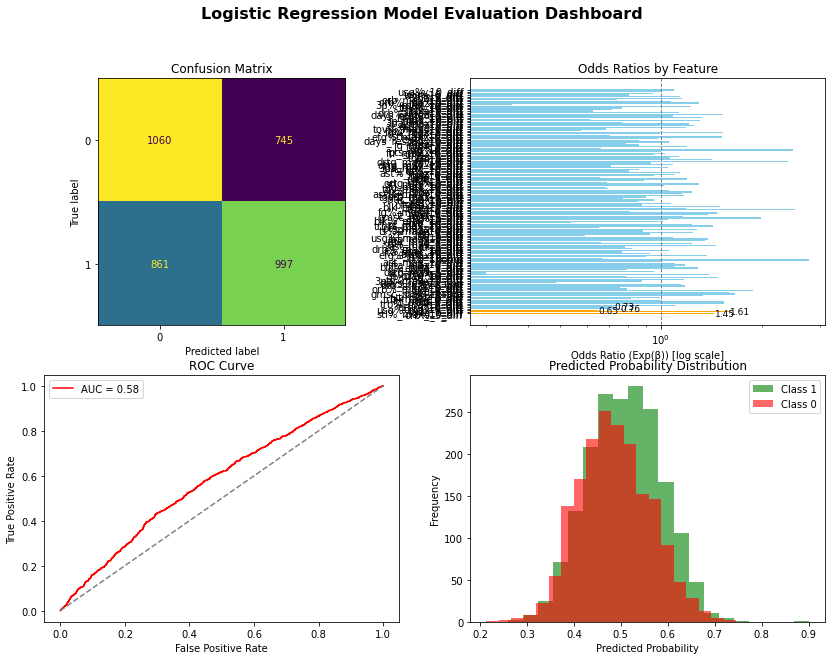

Model saved to saved_models\Logistic Regression Model.pkl


In [29]:
from sklearn.linear_model import LogisticRegression

predictors = selected_columns
model = LogisticRegression(max_iter=1000)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Logistic Regression Model")
save_model(model, predictors, feature_importance, model_name="Logistic Regression Model", folder="saved_models")

### Random Forest
__Type__: Both  
__For__: General-purpose baseline  
__Pros__: Reduces overfitting, robust, good accuracy  
__Cons__: Slower, less interpretable  

Note: 2001 (Breiman); got-to tabular model

              precision    recall  f1-score   support

           0       0.53      0.58      0.55      1805
           1       0.55      0.49      0.52      1858

    accuracy                           0.54      3663
   macro avg       0.54      0.54      0.54      3663
weighted avg       0.54      0.54      0.54      3663



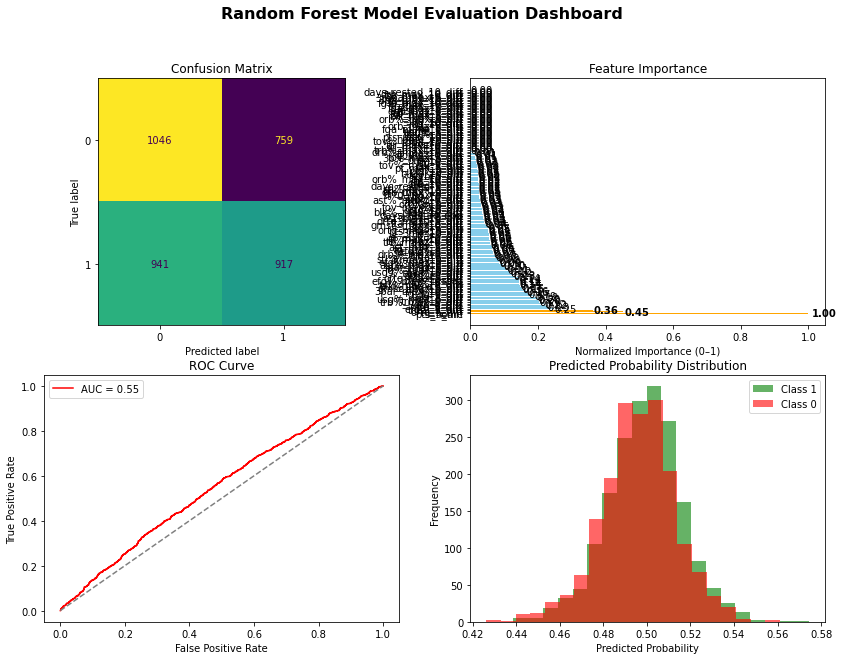

Model saved to saved_models\Random Forest Model.pkl


In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=2, random_state=0)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Random Forest Model")
save_model(model, predictors, feature_importance, model_name="Random Forest Model", folder="saved_models")

### Gradient Boosting (XGBoost, LightGBM)
__Type__: Both  
__For__: Tabular, structured data (competition winner)  
__Pros__: High accuracy, feature importance  
__Cons__: Harder to tune, longer training  

Note: 2014-2017; top Kaggle performers

              precision    recall  f1-score   support

           0       0.54      0.54      0.54      1805
           1       0.55      0.55      0.55      1858

    accuracy                           0.54      3663
   macro avg       0.54      0.54      0.54      3663
weighted avg       0.54      0.54      0.54      3663



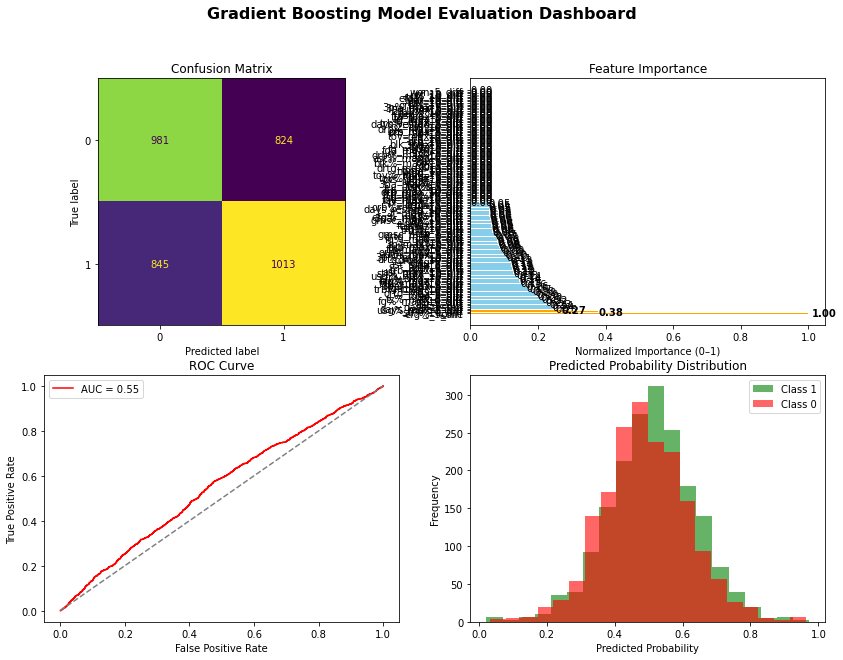

Model saved to saved_models\Gradient Boosting Model.pkl


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0)
model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "Gradient Boosting Model")
save_model(model, predictors, feature_importance, model_name="Gradient Boosting Model", folder="saved_models")

In [32]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


              precision    recall  f1-score   support

           0       0.54      0.53      0.54      1805
           1       0.55      0.55      0.55      1858

    accuracy                           0.54      3663
   macro avg       0.54      0.54      0.54      3663
weighted avg       0.54      0.54      0.54      3663



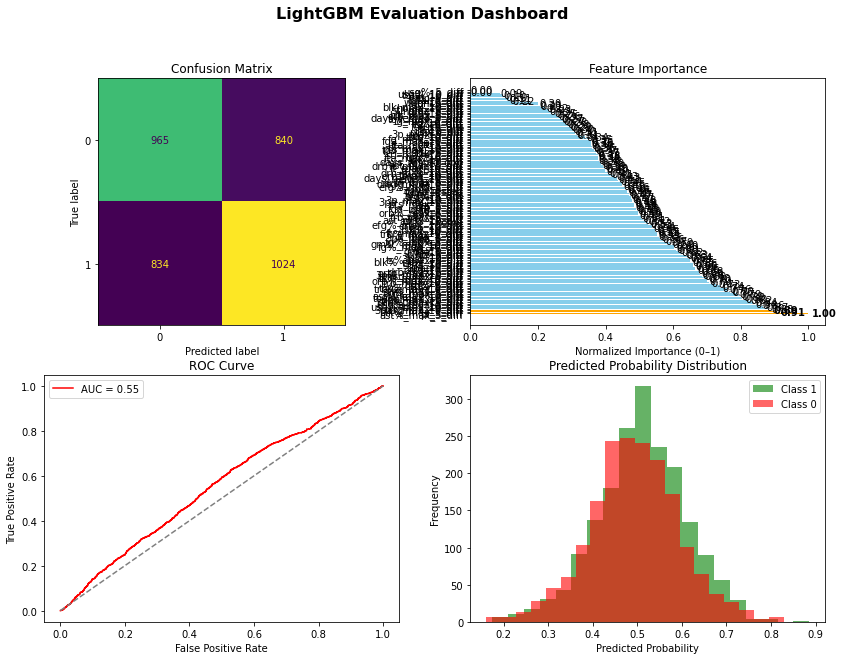

Model saved to saved_models\LightGBM.pkl


In [33]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model, feature_importance = evaluation_dashboard(df, model, predictors, "won", "LightGBM")
save_model(model, predictors, feature_importance, model_name="LightGBM", folder="saved_models")

In [34]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


C:\ProgramData\Anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [12:41:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.53      0.52      0.52      1805
           1       0.54      0.55      0.55      1858

    accuracy                           0.53      3663
   macro avg       0.53      0.53      0.53      3663
weighted avg       0.53      0.53      0.53      3663



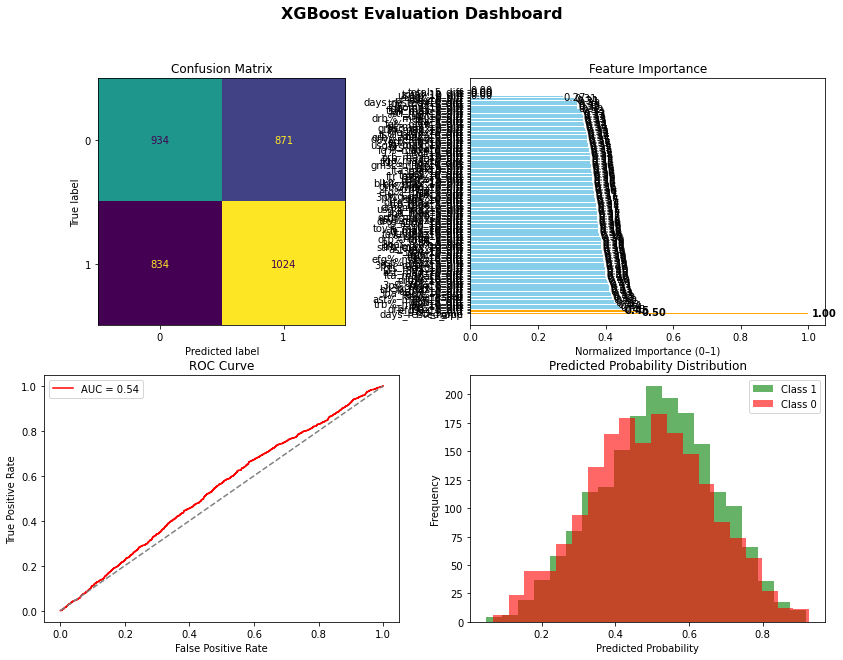

Model saved to saved_models\XGBoost.pkl


In [35]:
from xgboost import XGBClassifier

# Define XGBoost model
model = XGBClassifier(
    n_estimators=500,        # equivalent to iterations
    max_depth=6,             # equivalent to CatBoost depth
    learning_rate=0.05,
    objective='binary:logistic',  # for binary classification
    eval_metric='auc',            # same as CatBoost AUC
    use_label_encoder=False,
    verbosity=1                  # 0=silent, 1=warning/info
)

# Evaluate model using your existing evaluation dashboard
model, feature_importance = evaluation_dashboard(
    df, model, predictors, "won", "XGBoost"
)

# Save the trained model and feature importance
save_model(
    model,
    predictors,
    feature_importance,
    model_name="XGBoost",
    folder="saved_models"
)

## Model Evaluation

Ways to improve accuracy:
- Change number of games used to calculate rolling average
- You could search backwards through feature selection
- Change the number of seasons to look previously through
- Incorporate players dataset
- Look into finding team vs team performance in their last x matches

Players Dataset:
- Name
- stats
- performance in last 10 games
- performance against next team in last x games played against them